# Quantum Reed-Muller (Steane $[[7,1,3]]$) Code

## 1. Introduction
Quantum Reed-Muller (RM) codes are a powerful family of CSS codes constructed from classical RM codes or their punctured versions. The Steane $[[7,1,3]]$ code is a prominent punctured RM code (specifically derived from the classical Hamming $[7,4,3]$ code). 

Unlike the Shor code, which uses 9 qubits to correct a single error by concatenating repetition codes, the QRM (Steane) code achieves the same distance ($d=3$) using only 7 qubits. Furthermore, because it is a **CSS code**, its X and Z error correction protocols are perfectly symmetrical, and it allows for transversal implementation of certain Clifford gates.



### 1.1 The Parity Check Matrix
The stabilizer generators are defined by the classical Hamming parity check matrix $H$:

$$
H = \begin{pmatrix} 
1 & 0 & 0 & 1 & 0 & 1 & 1 \\
0 & 1 & 0 & 1 & 1 & 0 & 1 \\
0 & 0 & 1 & 0 & 1 & 1 & 1
\end{pmatrix}
$$

Because this matrix is self-orthogonal ($H H^T = 0 \pmod 2$), we can use the exact same matrix for both our Z-stabilizers (to detect X errors) and X-stabilizers (to detect Z errors). 

* Each row of $H$ defines a stabilizer generator.
* For $Z$-checks: Row 1 means we check the parity of qubits 0, 3, 5, and 6 using $Z$ operators.
* For $X$-checks: Row 1 means we check the parity of the same qubits using $X$ operators.

---

## 2. Qiskit Implementation
This implementation builds the complete 13-qubit system (7 Data + 6 Ancilla) for explicit syndrome extraction. We use 3 ancillas for the $Z$-checks and 3 ancillas for the $X$-checks.

In [1]:
# Cell 1: Imports
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

print("Imports successful. Ready to build QRM Code.")


Imports successful. Ready to build QRM Code.


In [2]:
# Cell 2: Define the Quantum Reed-Muller Class
class QuantumReedMuller:
    def __init__(self):
        # 7 Data Qubits
        self.data = QuantumRegister(7, name='data')

        # 6 Ancilla Qubits (3 for Z-checks, 3 for X-checks)
        self.anc = QuantumRegister(6, name='anc')

        # Classical Registers for Syndromes
        self.sz = ClassicalRegister(3, name='sz') # Z-syndromes (detect X flips)
        self.sx = ClassicalRegister(3, name='sx') # X-syndromes (detect Z flips)

        # Final readout
        self.out = ClassicalRegister(7, name='readout')

        self.qc = QuantumCircuit(self.data, self.anc, self.sz, self.sx, self.out)

    def encode_logical_zero(self):
        """
        Encodes |0> into the logical |0>_L state of the Steane code.
        Generates a uniform superposition of all codewords in the dual code.
        """
        # Create superposition on the message qubits
        self.qc.h(self.data[0:3])

        # Parity generation based on the H matrix
        # q3 = q0 + q1
        self.qc.cx(self.data[0], self.data[3])
        self.qc.cx(self.data[1], self.data[3])
        # q4 = q1 + q2
        self.qc.cx(self.data[1], self.data[4])
        self.qc.cx(self.data[2], self.data[4])
        # q5 = q0 + q2
        self.qc.cx(self.data[0], self.data[5])
        self.qc.cx(self.data[2], self.data[5])
        # q6 = q0 + q1 + q2
        self.qc.cx(self.data[0], self.data[6])
        self.qc.cx(self.data[1], self.data[6])
        self.qc.cx(self.data[2], self.data[6])

        self.qc.barrier(label='Encoded')

    def measure_syndromes(self):
        """
        Non-destructive measurement of the 6 stabilizers.
        """
        # --- Z-Checks (Detect X errors) using Ancillas 0, 1, 2 ---
        # Row 1: Qubits 0, 3, 5, 6
        self.qc.cx(self.data[0], self.anc[0]); self.qc.cx(self.data[3], self.anc[0])
        self.qc.cx(self.data[5], self.anc[0]); self.qc.cx(self.data[6], self.anc[0])

        # Row 2: Qubits 1, 3, 4, 6
        self.qc.cx(self.data[1], self.anc[1]); self.qc.cx(self.data[3], self.anc[1])
        self.qc.cx(self.data[4], self.anc[1]); self.qc.cx(self.data[6], self.anc[1])

        # Row 3: Qubits 2, 4, 5, 6
        self.qc.cx(self.data[2], self.anc[2]); self.qc.cx(self.data[4], self.anc[2])
        self.qc.cx(self.data[5], self.anc[2]); self.qc.cx(self.data[6], self.anc[2])

        # --- X-Checks (Detect Z errors) using Ancillas 3, 4, 5 ---
        self.qc.h(self.anc[3:6]) # Basis change for X measurements

        # Row 1
        self.qc.cx(self.anc[3], self.data[0]); self.qc.cx(self.anc[3], self.data[3])
        self.qc.cx(self.anc[3], self.data[5]); self.qc.cx(self.anc[3], self.data[6])
        # Row 2
        self.qc.cx(self.anc[4], self.data[1]); self.qc.cx(self.anc[4], self.data[3])
        self.qc.cx(self.anc[4], self.data[4]); self.qc.cx(self.anc[4], self.data[6])
        # Row 3
        self.qc.cx(self.anc[5], self.data[2]); self.qc.cx(self.anc[5], self.data[4])
        self.qc.cx(self.anc[5], self.data[5]); self.qc.cx(self.anc[5], self.data[6])

        self.qc.h(self.anc[3:6])

        # Measure
        self.qc.measure(self.anc[0:3], self.sz)
        self.qc.measure(self.anc[3:6], self.sx)
        self.qc.barrier(label='Syndrome Extracted')

    def apply_correction(self):
        """
        Applies dynamic correction. The binary value of the syndrome
        points directly to the index of the faulty qubit!
        """
        # Dictionary mapping integer syndrome to qubit index
        # Synergy of the Hamming matrix:
        # syn=1 (001)->q0, syn=2 (010)->q1, syn=4 (100)->q2
        # syn=3 (011)->q3, syn=6 (110)->q4, syn=5 (101)->q5, syn=7 (111)->q6

        # Correct X Errors (Bit flips) using Z-syndrome
        with self.qc.if_test((self.sz, 1)): self.qc.x(self.data[0])
        with self.qc.if_test((self.sz, 2)): self.qc.x(self.data[1])
        with self.qc.if_test((self.sz, 4)): self.qc.x(self.data[2])
        with self.qc.if_test((self.sz, 3)): self.qc.x(self.data[3])
        with self.qc.if_test((self.sz, 6)): self.qc.x(self.data[4])
        with self.qc.if_test((self.sz, 5)): self.qc.x(self.data[5])
        with self.qc.if_test((self.sz, 7)): self.qc.x(self.data[6])

        # Correct Z Errors (Phase flips) using X-syndrome
        with self.qc.if_test((self.sx, 1)): self.qc.z(self.data[0])
        with self.qc.if_test((self.sx, 2)): self.qc.z(self.data[1])
        with self.qc.if_test((self.sx, 4)): self.qc.z(self.data[2])
        with self.qc.if_test((self.sx, 3)): self.qc.z(self.data[3])
        with self.qc.if_test((self.sx, 6)): self.qc.z(self.data[4])
        with self.qc.if_test((self.sx, 5)): self.qc.z(self.data[5])
        with self.qc.if_test((self.sx, 7)): self.qc.z(self.data[6])

        self.qc.barrier(label='Corrected')

    def decode_and_verify(self):
        """
        Uncomputes the encoding sequence. If correct, returns to |0000000>.
        """
        self.qc.cx(self.data[0], self.data[6]); self.qc.cx(self.data[1], self.data[6]); self.qc.cx(self.data[2], self.data[6])
        self.qc.cx(self.data[0], self.data[5]); self.qc.cx(self.data[2], self.data[5])
        self.qc.cx(self.data[1], self.data[4]); self.qc.cx(self.data[2], self.data[4])
        self.qc.cx(self.data[0], self.data[3]); self.qc.cx(self.data[1], self.data[3])

        self.qc.h(self.data[0:3])
        self.qc.measure(self.data, self.out)
        return self.qc


---

## 3. Performance Simulation
To evaluate the performance of the Steane $[[7,1,3]]$ code, we inject independent depolarizing noise ($X$, $Y$, or $Z$) on all 7 qubits. 

Because the CSS construction separates $X$ and $Z$ tracking, the code can occasionally correct weight-2 errors if they occur in different bases (for example, an $X$ error on $q_0$ and a $Z$ error on $q_1$). However, the theoretical worst-case bound assumes the code fails if *any* 2 or more errors occur across the 7 qubits. 

We will compare our simulated logical error rate against the theoretical worst-case failure probability:
$$P_{theory} = 1 - (1-p)^7 - 7p(1-p)^6$$

Simulating 8 points...
p=0.0010 -> P_Logical=0.0000
p=0.0021 -> P_Logical=0.0000
p=0.0043 -> P_Logical=0.0000
p=0.0088 -> P_Logical=0.0000
p=0.0181 -> P_Logical=0.0040
p=0.0373 -> P_Logical=0.0120
p=0.0769 -> P_Logical=0.0507
p=0.1585 -> P_Logical=0.1273


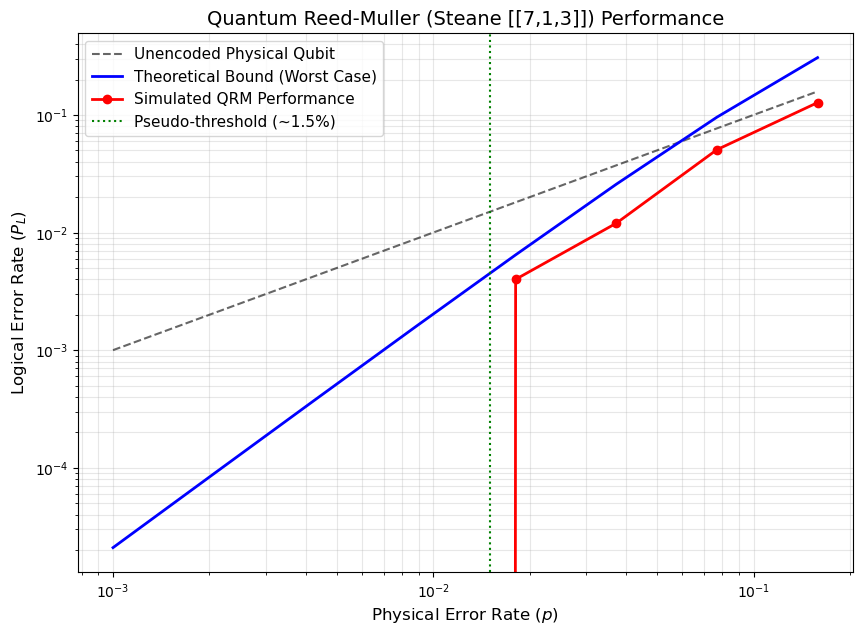

In [3]:
# Cell 3: Simulation and Plotting
def apply_random_noise(qrm_instance, p):
    for qubit_idx in range(7):
        if np.random.random() < p:
            error_type = np.random.choice(['X', 'Y', 'Z'])
            if error_type == 'X': qrm_instance.qc.x(qrm_instance.data[qubit_idx])
            elif error_type == 'Y': qrm_instance.qc.y(qrm_instance.data[qubit_idx])
            elif error_type == 'Z': qrm_instance.qc.z(qrm_instance.data[qubit_idx])

def run_qrm_simulation(p_values, shots_per_point=1000):
    logical_error_rates = []
    backend = AerSimulator(method='stabilizer') # Stabilizer is fast and handles CSS

    print(f"Simulating {len(p_values)} points...")
    for p in p_values:
        failures = 0
        circuits = []

        for _ in range(shots_per_point):
            qrm = QuantumReedMuller()
            qrm.encode_logical_zero()
            apply_random_noise(qrm, p)
            qrm.measure_syndromes()
            qrm.apply_correction()
            circuits.append(qrm.decode_and_verify())

        result = backend.run(circuits, shots=1, optimization_level=0).result()

        for i in range(shots_per_point):
            counts = result.get_counts(i)
            outcome = list(counts.keys())[0]
            readout = outcome.split(" ")[0]
            if readout != '0000000':
                failures += 1

        p_logical = failures / shots_per_point
        logical_error_rates.append(p_logical)
        print(f"p={p:.4f} -> P_Logical={p_logical:.4f}")

    return logical_error_rates

# 1. Define physical error rates
p_phys_samples = np.logspace(-3, -0.8, 8)

# 2. Run simulation
p_log_simulated = run_qrm_simulation(p_phys_samples, shots_per_point=1500)

# 3. Calculate Theoretical Bounds
# Worst-case failure: 2 or more errors anywhere
p_theoretical = 1 - (1 - p_phys_samples)**7 - 7 * p_phys_samples * (1 - p_phys_samples)**6

# 4. Plotting
plt.figure(figsize=(10, 7))

plt.loglog(p_phys_samples, p_phys_samples, 'k--', label='Unencoded Physical Qubit', alpha=0.6)
plt.loglog(p_phys_samples, p_theoretical, 'b-', label='Theoretical Bound (Worst Case)', linewidth=2)
plt.loglog(p_phys_samples, p_log_simulated, 'ro-', label='Simulated QRM Performance', linewidth=2)

plt.axvline(x=0.015, color='green', linestyle=':', label='Pseudo-threshold (~1.5%)')

plt.title('Quantum Reed-Muller (Steane [[7,1,3]]) Performance', fontsize=14)
plt.xlabel('Physical Error Rate ($p$)', fontsize=12)
plt.ylabel('Logical Error Rate ($P_L$)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="-", alpha=0.3)

plt.show()
